In [ ]:
# Download the tweet data for Russian: Protest (протест)
from Exporter import main
terms = 'протест'  ## this is the shortest particle representing protests
fnameout = "export.csv"
main(['--querysearch',terms,'--since', 
              '2019-07-01', 
          '--until','2019-09-28',
          '--maxtweets',
          '1000000',
  '--output',fnameout])

In [ ]:
# Next, import the export.csv file into google spreadsheets.  (click and drag the csv to "My Drive" then open it)
# create a new column after 'text' called 'english' and input the formulat =GOOGLETRANSLATE('text' field)
# after all the translations are done, choose Download as >> csv

In [1]:
# lookup the location of the df['english'] translated tweet field - takes about 1 sec per location
# todo: rewrite this as async/multiprocessing but the shelve is not async-compliant, so should sync() sequentially

# IMPORTANT: run this cell multiple times until there's no printout.  Each time it shelves its state
# so we can continue running this cell to get incremental results

# Scan in csv having 'english' translated column from 'text' (e.g. spanish)
import pandas as pd
csvname = 'russia_protest_jul_sep_2019_translated.csv'
shelf_name = csvname+'.shelf'
df = pd.read_csv(csvname)

from bulk_location import locations
import shelve

d = shelve.open(shelf_name)

from googlemaps.exceptions import TransportError
N = len(df)
for i,text in enumerate(df['english']):
    key = str(i)
    if key in d:
        continue
    try:
        print text
        locs = locations(text, ntop=3)
    except TransportError:
        continue
    d[key] = locs
    print i, N
    d.sync()

print len(d.keys()), len(df)
print 'done'
d.close()

26267 26267
done


In [2]:
# put location results into df['loc']
english_locs = shelve.open(shelf_name)
keys = [k for k in sorted([int(k) for k in sorted(english_locs.keys())])]  # keys must be strings; convert back to int & sort
eng_text = [english_locs[str(k)] for k in keys]
assert len(eng_text) == len(df)
df['loc'] = eng_text

# convert datetime to native pandas
df['date'] = pd.to_datetime(df['date'])

## get a lat, lon from the places information
def resolve_location_first_latlon(row):
    if not row:
        return None,None
    for element in row:
        if element[2] != '' and element[3] != '':
            ##print element
            return element[4],float(element[2]), float(element[3])
    return None,None

# Export Russia-related places more specific than country
russia_locations = [bool(p and p != [] and u'countrypolitical' not in p[0] and 'Russia' in p[0][4]) for p in df['loc']]

fname = 'russia_protest_jul_sep_2019_translated_locations.csv'

print any(russia_locations)
print sum(russia_locations)
places, lats,lons = zip(*[resolve_location_first_latlon(d) for d in df[russia_locations]['loc']])
print len(lats), len(lons)
# fill in default lat/lon/place name for non-MX results (won't show up in output)
df['lat'] = 0.
df['lon'] = 0.
df['place name'] = None
# break out (lat, lon, place name) into separate columns
df.loc[russia_locations, 'lat'] = lats
df.loc[russia_locations, 'lon'] = lons
df.loc[russia_locations, 'place name'] = places
# inspection of df - max date
min(df['date']), max(df['date'])

df[russia_locations].to_csv(fname, header=True, index=False, encoding='utf-8')
# dates: 2019-06-30 to 2019-09-22 

True
2327
2327 2327


In [3]:
# duplicates?

# 1862 unique 
print len(set(df[russia_locations]['english']))

## 2327 Russia tweets with location, 1862 of them are unique tweets
print sum(russia_locations)

russia_locations_with_country = [bool(p and p != [] and 'Russia' in p[0][4]) for p in df['loc']]
# 3508 Russia (inc. those specific to country)
print sum(russia_locations_with_country) 

1862
2327
3508


In [5]:
import pycountry
all_countries = [c.name.lower() for c in pycountry.countries]
[ac for ac in all_countries if 'ussia' in ac]
all_countries.remove('russian federation')
all_countries += ['russia']

# calculate country attribution to overall tweet amounts: 3.5K russia, 1.1K US, 1.0K ukraine
from collections import Counter
c = Counter()
for p in df['loc']:
    if p and p != []:
        x = p[0][4].lower()
        s = [cc.strip() for cc in x.split(',')]
        overlap = set(s) & set(all_countries)
        if overlap == set():
            pass
        else:
            c.update(overlap)
print c.most_common()

[(u'russia', 3508), (u'united states', 1097), (u'ukraine', 1031), (u'hong kong', 314), (u'france', 169), (u'japan', 152), (u'bulgaria', 144), (u'china', 106), (u'georgia', 102), (u'germany', 67), (u'serbia', 66), (u'armenia', 45), (u'italy', 37), (u'lithuania', 37), (u'latvia', 33), (u'belarus', 30), (u'united kingdom', 29), (u'north macedonia', 28), (u'canada', 25), (u'israel', 24), (u'kazakhstan', 24), (u'estonia', 23), (u'czechia', 23), (u'romania', 19), (u'india', 18), (u'turkey', 17), (u'spain', 17), (u'greece', 16), (u'poland', 15), (u'egypt', 13), (u'bosnia and herzegovina', 12), (u'switzerland', 12), (u'brazil', 11), (u'mexico', 9), (u'hungary', 9), (u'netherlands', 8), (u'azerbaijan', 7), (u'australia', 6), (u'puerto rico', 6), (u'kyrgyzstan', 6), (u'sudan', 4), (u'luxembourg', 4), (u'norway', 4), (u'belgium', 4), (u'lebanon', 4), (u'denmark', 4), (u'jordan', 3), (u'austria', 3), (u'ethiopia', 3), (u'qatar', 3), (u'zimbabwe', 3), (u'slovakia', 3), (u'albania', 3), (u'cuba', 3)

[(u'russia', 3508), (u'united states', 1097), (u'ukraine', 1031), (u'hong kong', 314), (u'france', 169), (u'japan', 152), (u'bulgaria', 144), (u'china', 106), (u'georgia', 102), (u'germany', 67), (u'serbia', 66), (u'armenia', 45), (u'italy', 37), (u'lithuania', 37), (u'latvia', 33), (u'belarus', 30), (u'united kingdom', 29), (u'north macedonia', 28), (u'canada', 25), (u'israel', 24), (u'kazakhstan', 24), (u'estonia', 23), (u'czechia', 23), (u'romania', 19), (u'india', 18), (u'turkey', 17), (u'spain', 17), (u'greece', 16), (u'poland', 15), (u'egypt', 13), (u'bosnia and herzegovina', 12), (u'switzerland', 12), (u'brazil', 11), (u'mexico', 9), (u'hungary', 9), (u'netherlands', 8), (u'azerbaijan', 7), (u'australia', 6), (u'puerto rico', 6), (u'kyrgyzstan', 6), (u'sudan', 4), (u'luxembourg', 4), (u'norway', 4), (u'belgium', 4), (u'lebanon', 4), (u'denmark', 4), (u'jordan', 3), (u'austria', 3), (u'ethiopia', 3), (u'qatar', 3), (u'zimbabwe', 3), (u'slovakia', 3), (u'albania', 3), (u'cuba', 3)

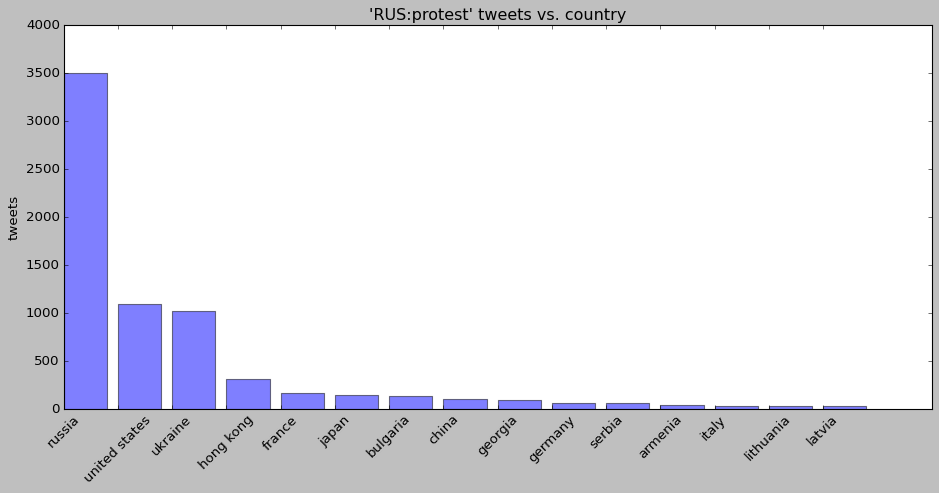

In [6]:
# plot country attribution
%matplotlib inline

import matplotlib
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt; plt.rcdefaults()
import numpy as np
import matplotlib.pyplot as plt

objects, performance = zip(*c.most_common()[:15])
print c.most_common()
##objects = ('Python', 'C++', 'Java', 'Perl', 'Scala', 'Lisp')
y_pos = np.arange(len(objects))
##performance = [10,8,6,4,2,1]

# Get current size
fig_size = plt.rcParams["figure.figsize"]
 
# Prints: [8.0, 6.0]
print "Current size:", fig_size
 
# Set figure width to 12 and height to 9
fig_size[0] = 14
fig_size[1] = 6
plt.rcParams["figure.figsize"] = fig_size

plt.bar(y_pos, performance, alpha=0.5)
plt.xticks(y_pos, objects,size=12)
plt.xticks(rotation=45)
plt.ylabel('tweets')
plt.title("'RUS:protest' tweets vs. country")
plt.show()

In [40]:
# isolate only russia non-country locations
from collections import Counter
ix = []
for p in df['loc']:
    if p and p != []:
        x = p[0][4].lower()
        y = p[0][5].lower()
        if y == 'countrypolitical' and x == 'russia':
            ix += [False]
            continue
        s = [cc.strip() for cc in x.split(',')]
        overlap = set(s) & set(['russia'])
        if overlap != set():
            ix += [True]
            continue
        ix += [False]
    else:
        ix += [False]
print sum(ix)
s = set()
places = Counter()
for p in df[ix]['loc']:
    k = tuple(p[0][:4])
    places[k] += 1
places_common = [(p,mc) for p,mc in places.most_common() if mc > 10]
places_common

2327


[((u'Moscow', u'GPE', 55.755826, 37.6172999), 1512),
 ((u'Buryatia', u'GPE', 54.83311459999999, 112.406053), 122),
 ((u'Siberia', u'LOC', 61.01370970000001, 99.1966559), 85),
 ((u'MOSCOW', u'GPE', 55.755826, 37.6172999), 50),
 ((u'Kremlin', u'GPE', 55.7520233, 37.6174994), 47),
 ((u'Moscow City Duma', u'GPE', 55.7684009, 37.6118919), 32),
 ((u'Yekaterinburg', u'GPE', 56.83892609999999, 60.6057025), 30),
 ((u'Moscow City', u'GPE', 55.755826, 37.6172999), 28),
 ((u'the Kuril Islands', u'LOC', 47.15439809999999, 150.9705378), 22),
 ((u'Sakharov Avenue', u'FAC', 55.7705001, 37.6441108), 19),
 ((u'Ekaterinburg', u'GPE', 56.83892609999999, 60.6057025), 16),
 ((u'Kurils', u'GPE', 47.15439809999999, 150.9705378), 15),
 ((u'Novosibirsk', u'GPE', 55.00835259999999, 82.9357327), 15),
 ((u'Ulan Ude', u'FAC', 51.8238785, 107.607338), 14),
 ((u'Leningrad', u'GPE', 59.9342802, 30.3350986), 11)]

In [42]:
# Compute the days where tweets are present, by location
print sum(ix)

from collections import defaultdict, Counter
def myfn():
    return 0
y_ix = defaultdict(myfn)
cnt = defaultdict(myfn)
for x in df[ix][['date','loc','english','retweets']].iterrows():
    dt,p,english, rt = x[1]
    k = tuple(p[0][:4])
    key_date = dt.date()
    key_date,k, english
    cnt[(tuple(k),key_date)] += 1+rt
    y_ix[(tuple(k),key_date)] = 1
                  
##len(set([p for p,k in cnt.keys()]))  ## 154 territories
common = [p for p,mc in places_common]
## filter by top ones only
[(p,k) for p,k in cnt.keys() if p in common]

2327


[((u'Novosibirsk', u'GPE', 55.00835259999999, 82.9357327),
  datetime.date(2019, 8, 5)),
 ((u'Kremlin', u'GPE', 55.7520233, 37.6174994), datetime.date(2019, 8, 29)),
 ((u'Moscow City Duma', u'GPE', 55.7684009, 37.6118919),
  datetime.date(2019, 7, 15)),
 ((u'Moscow', u'GPE', 55.755826, 37.6172999), datetime.date(2019, 7, 12)),
 ((u'Moscow City Duma', u'GPE', 55.7684009, 37.6118919),
  datetime.date(2019, 8, 10)),
 ((u'Moscow', u'GPE', 55.755826, 37.6172999), datetime.date(2019, 7, 31)),
 ((u'Novosibirsk', u'GPE', 55.00835259999999, 82.9357327),
  datetime.date(2019, 7, 6)),
 ((u'Ulan Ude', u'FAC', 51.8238785, 107.607338), datetime.date(2019, 9, 10)),
 ((u'Kremlin', u'GPE', 55.7520233, 37.6174994), datetime.date(2019, 8, 22)),
 ((u'Moscow', u'GPE', 55.755826, 37.6172999), datetime.date(2019, 7, 30)),
 ((u'Moscow City Duma', u'GPE', 55.7684009, 37.6118919),
  datetime.date(2019, 8, 9)),
 ((u'Sakharov Avenue', u'FAC', 55.7705001, 37.6441108),
  datetime.date(2019, 8, 11)),
 ((u'Moscow Cit

In [43]:
# need: contribution of each place + y_after
import datetime

start = datetime.date(2019, 7, 1)
end = datetime.date(2019, 9, 21)
seq = [start + datetime.timedelta(days=x) for x in range(0, (end-start).days)]

ix = 2
##for place in common:
    ##print place
from csv import writer
with open('train.csv','w') as f:
    cf = writer(f)
    yplace = common[ix]
    for date in seq:
        predict_date = date + datetime.timedelta(days=1)
        ##print date.strftime('%Y%m%d')
        y_predict = y_ix[(yplace,predict_date)]
        xx = [cnt[(place, date)] for place in common]
        out_row = [y_predict,] + xx 
        cf.writerow(out_row)
        
from csv import reader
with open('train.csv') as f:
    cf = reader(f)
    for row in cf:
        print row

['0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0']
['0', '9', '0', '0', '0', '14', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0']
['0', '7', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0']
['0', '15', '0', '0', '0', '0', '0', '0', '0', '23', '0', '0', '6', '0', '0', '0']
['0', '11', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '3', '0', '0', '0']
['0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '2', '0', '1', '0', '0']
['0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0']
['0', '0', '0', '0', '0', '0', '0', '3', '0', '0', '0', '0', '1', '0', '0', '0']
['0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0']
['0', '12', '0', '0', '0', '0', '0', '0', '1', '0', '0', '0', '0', '0', '0', '0']
['0', '12', '0', '0', '0', '0', '0', '1', '0', '0', '0', '0', '0', '0', '0', '0']
['0', '12', '0', '0', '0', '0', '0', '0', '0', '0', '0', '1', '0', '0', '0', '0']
['0', '1', '0', '0', 

In [11]:
[c[0] for c in common]

[u'Moscow',
 u'Buryatia',
 u'Siberia',
 u'MOSCOW',
 u'Kremlin',
 u'Moscow City Duma',
 u'Yekaterinburg',
 u'Moscow City',
 u'the Kuril Islands',
 u'Sakharov Avenue',
 u'Ekaterinburg',
 u'Kurils',
 u'Novosibirsk',
 u'Ulan Ude',
 u'Leningrad']

('rf Mean Absolute Error:', 0.0, 'Prob(hail).')
rf mse: 0.0
len(clf.estimators_) =  6


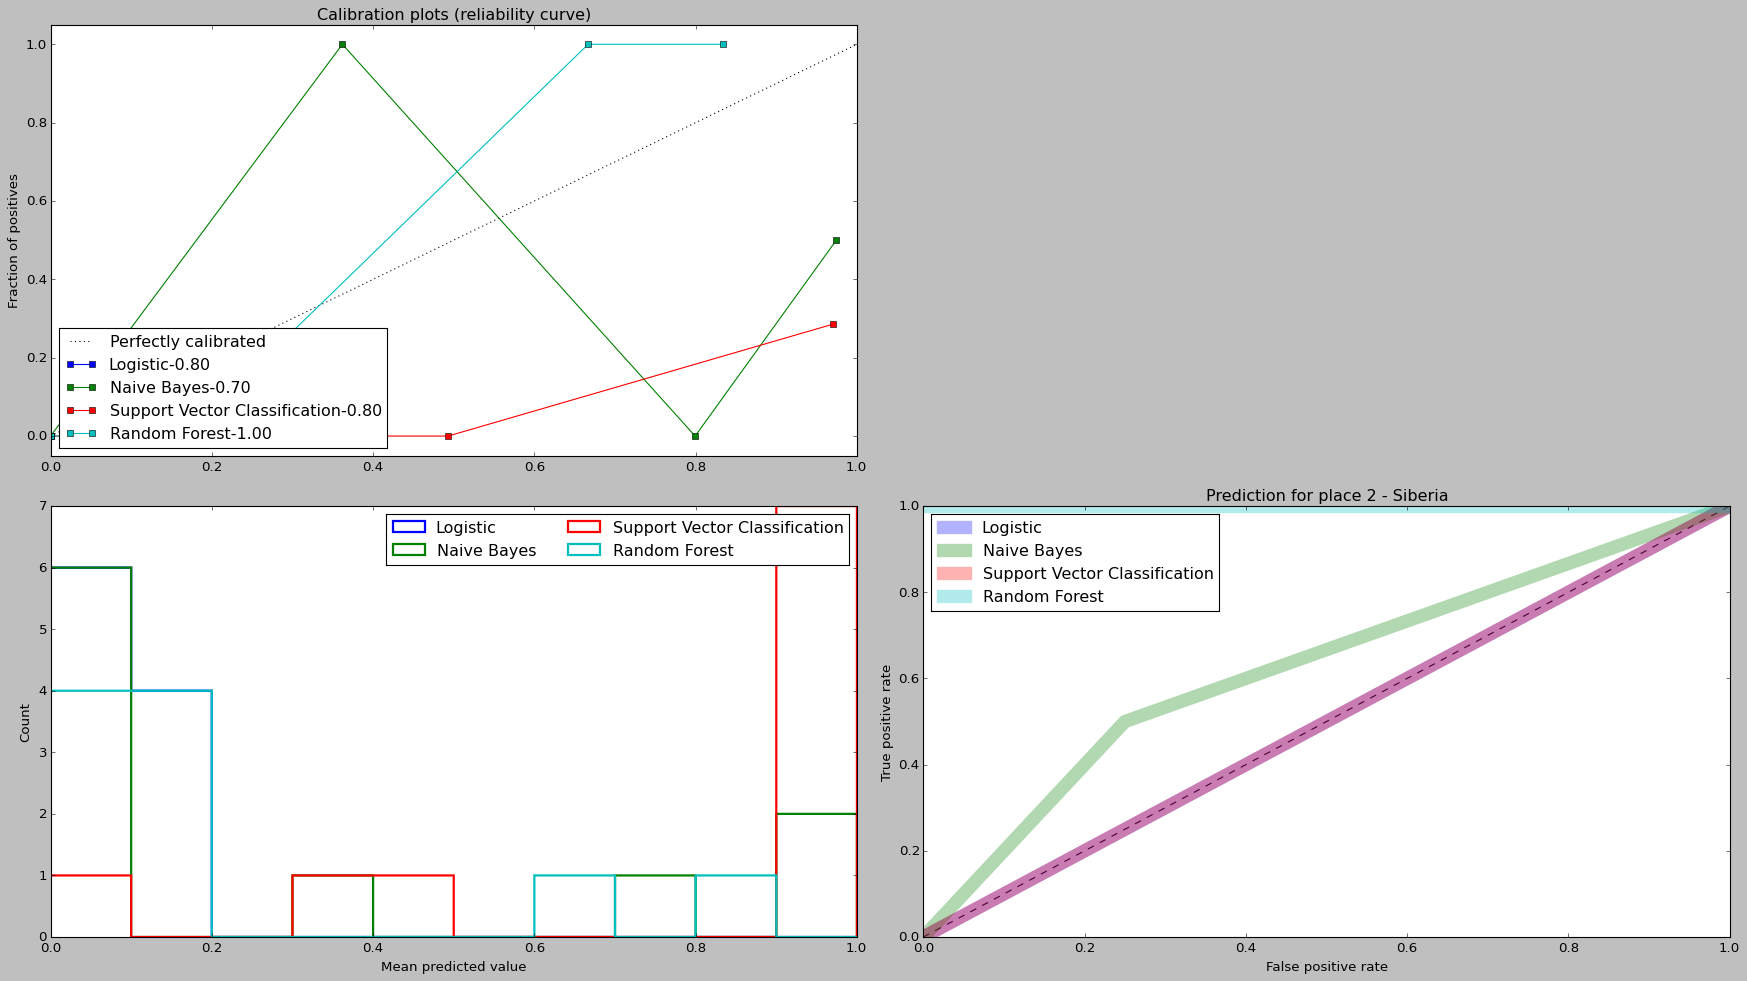

In [46]:
import numpy as np
np.random.seed(0)

import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import calibration_curve
from sklearn import metrics

from sklearn.tree import export_graphviz
import pydot

from sklearn.metrics import roc_curve

def data(fname):
    with open(fname) as f:
        from csv import reader
        rf = reader(f)
        train = []
        y = []
        for i,row in enumerate(rf):
            ##if i == 0:
            ##    continue
            train_row= [float(r) for r in row[1:]]
            ##print row
            train += [train_row,]
            y += [float(row[0]),]
    return y, train

yy,train = data('train.csv')

# Create classifiers
lr = LogisticRegression(solver='lbfgs')
gnb = GaussianNB()
svc = LinearSVC(C=1.0)
rfc = RandomForestClassifier(n_estimators=6)


plt.figure(figsize=(22, 18))
##ax1 = plt.subplot2grid((3, 1), (0, 0), rowspan=2)
ax1 = plt.subplot2grid((3, 2), (0, 0))
ax2 = plt.subplot2grid((3, 2), (1, 0))
##ax3 = plt.subplot2grid((3, 2), (0, 1))
ax4 = plt.subplot2grid((3, 2), (1, 1))

ax1.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
rf = None
y_pred_rf = None
rocs = []
X_train = train
y_train = yy
X_test = np.array(train[-10:])
y_test = np.array(yy[-10:])
for clf, name in [
        (lr, 'Logistic'),
                  (gnb, 'Naive Bayes'),
                  (svc, 'Support Vector Classification'),
                  (rfc, 'Random Forest')]:
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    ##raise Exception((y_test, y_pred))
    rocs += [(fpr, tpr, name),]
    ##raise Exception(rocs)

    if name == 'Random Forest':
        y_pred_rf = y_pred
        errors = np.abs(y_pred_rf - y_test)
        print('rf Mean Absolute Error:', round(np.mean(errors), 2),
                'Prob(hail).')
        # Calculate mean absolute percentage error (MAPE)
        mse = metrics.mean_squared_error(y_test, y_pred_rf)
        print 'rf mse:', mse
        ##raise Exception('stop')
        if 0:
            mape = 100 * (errors / y_test)
            # Calculate and display accuracy
            accuracy = 100 - np.mean(mape)
            print('Accuracy:', round(accuracy, 2), '%.')
        if 1:
            feature_list = [c[0] for c in common]
        print 'len(clf.estimators_) = ', len(clf.estimators_)
        for i,clf_estimator in enumerate(clf.estimators_):
            tree = clf_estimator
            # Export the image to a dot file
            export_graphviz(tree, out_file = 'tree_%d.dot' % i, feature_names = feature_list, rounded = True, precision = 1)
            # Use dot file to create a graph
            if 1:
                import pygraphviz as pgv
                G = pgv.AGraph("tree_%d.dot" % i)
                G.draw('rf_out_%d.png' % i,prog='dot')
            if 0:
                (graph, ) = pydot.graph_from_dot_file('tree.dot')
                # Write graph to a png file
                graph.write_png('tree.png')
    score = clf.score(X_test, y_test)
    if hasattr(clf, "predict_proba"):
        prob_pos = clf.predict_proba(X_test)[:, 1]
    else:  # use decision function
        prob_pos = clf.decision_function(X_test)
        prob_pos = \
            (prob_pos - prob_pos.min()) / (prob_pos.max() - prob_pos.min())
    fraction_of_positives, mean_predicted_value = \
        calibration_curve(y_test, prob_pos, n_bins=10)

    ax1.plot(mean_predicted_value, fraction_of_positives, "s-",
             label="%s-%.2f" % (name, score))

    ax2.hist(prob_pos, range=(0, 1), bins=10, label=name,
             histtype="step", lw=2)

ax1.set_ylabel("Fraction of positives")
ax1.set_ylim([-0.05, 1.05])
ax1.legend(loc="lower left")
ax1.set_title('Calibration plots (reliability curve)')

if 1:
    ax2.set_xlabel("Mean predicted value")
    ax2.set_ylabel("Count")
    ax2.legend(loc="best", ncol=2)

if 0:
    w = np.where(y_test != y_pred_rf)
    n_error = w[0].shape[0]+0.
    pct_error = n_error/y_test.shape[0]

    ax3.plot(y_test, y_pred_rf, 'b.', linewidth=3, alpha=0.01)
    ax3.set_xlabel('truth')
    ax3.set_ylabel('P(hail), test_error = %.3f (%d/%d)' % (pct_error, n_error, y_test.shape[0]))

##raise Exception(pct_error)
##raise Exception((y_test, y_pred_rf))
##plt.figure(1)
ax4.plot([0, 1], [0, 1], 'k--')
##ax4.plot(fpr_rt_lm, tpr_rt_lm, label='RT + LR')
for x,y,name in rocs:
    ##ax4.plot(fpr_rf, tpr_rf, label='RF')
    ax4.plot(x, y, label=name, alpha=0.3, linewidth=12)
    ##raise Exception((x,y))
##ax4.plot(fpr_rf_lm, tpr_rf_lm, label='RF + LR')
##plt.plot(fpr_grd, tpr_grd, label='GBT')
##plt.plot(fpr_grd_lm, tpr_grd_lm, label='GBT + LR')
ax4.set_xlabel('False positive rate')
ax4.set_ylabel('True positive rate')
ax4.set_title('ROC curve')
ax4.legend(loc='best')
plt.title('Prediction for place %d - %s' % (ix,common[ix][0]))
##plt.show()

plt.tight_layout()
plt.show()



In [47]:
print y_pred
print y_test
print X_test

[0. 0. 0. 0. 1. 0. 1. 0. 0. 0.]
[0. 0. 0. 0. 1. 0. 1. 0. 0. 0.]
[[ 4. 51.  0.  1.  0.  0.  0.  0.  0.  0.  1.  0.  0.  7.  0.]
 [10. 77.  0.  0.  0.  0. 16.  0.  0.  0.  0.  0.  0.  5.  0.]
 [ 7. 12.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  2.  0.]
 [ 1.  3.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  3.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [23.  5.  1.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 3.  5.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 9. 15.  1.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [11. 33.  0.  0.  2.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 5. 28.  0.  6.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]]
